In [ ]:
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split

In [ ]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
train_transform = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

full_train = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=train_transform)
test_ds = torchvision.datasets.MNIST(root="./data", train=False, download=True, transform=test_transform)

train_ds, val_ds = random_split(full_train, [50000, 10000])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 482kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.69MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.6MB/s]


In [ ]:
class BaselineModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(784, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.fc(x)


class DeepModel(nn.Module):
    def __init__(self, activation='relu', use_regularization=True):
        super().__init__()

        acts = {
            'relu': nn.ReLU(),
            'sigmoid': nn.Sigmoid(),
            'leaky': nn.LeakyReLU(0.01)
        }
        self.act = acts[activation]
        self.use_regularization = use_regularization

        self.fc1 = nn.Linear(784, 256)
        self.bn1 = nn.BatchNorm1d(256) if use_regularization else nn.Identity()

        self.fc2 = nn.Linear(256, 256)
        self.bn2 = nn.BatchNorm1d(256) if use_regularization else nn.Identity()

        self.dropout = nn.Dropout(0.5) if use_regularization else nn.Identity()
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x1 = self.act(self.bn1(self.fc1(x)))
        x2 = self.act(self.bn2(self.fc2(x1)))
        x = x1 + x2
        x = self.dropout(x)
        return self.fc3(x)

In [ ]:
def accuracy_fn(logits, labels):
    preds = torch.argmax(logits, dim=1)
    return (preds == labels).float().mean().item() * 100


def evaluate(model, loader, criterion, loss_type='cce'):
    model.eval()
    total_loss = 0
    total_acc = 0
    n_batches = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            if loss_type == 'mse':
                targets = F.one_hot(labels, num_classes=10).float()
                probs = torch.softmax(outputs, dim=1)
                loss = criterion(probs, targets)
            else:
                loss = criterion(outputs, labels)

            acc = accuracy_fn(outputs, labels)

            total_loss += loss.item()
            total_acc += acc
            n_batches += 1

    return total_loss / n_batches, total_acc / n_batches

In [ ]:
def run_experiment(model, loss_type='cce', epochs=5, lr=0.01, use_regularization=True):
    model = model.to(device)

    if loss_type == 'cce':
        criterion = nn.CrossEntropyLoss(label_smoothing=0.1 if use_regularization else 0.0)
    else:
        criterion = nn.MSELoss()

    optimizer = optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=0.9,
        weight_decay=1e-4 if use_regularization else 0.0
    )

    history = {
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': []
    }

    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = float('inf')
    patience = 2
    wait = 0

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        total_train_acc = 0
        n_batches = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            if loss_type == 'mse':
                targets = F.one_hot(labels, num_classes=10).float()
                probs = torch.softmax(outputs, dim=1)
                loss = criterion(probs, targets)
            else:
                loss = criterion(outputs, labels)

            if use_regularization:
                l1_penalty = sum(p.abs().sum() for p in model.parameters())
                loss = loss + 1e-5 * l1_penalty

            loss.backward()
            optimizer.step()

            acc = accuracy_fn(outputs.detach(), labels)

            total_train_loss += loss.item()
            total_train_acc += acc
            n_batches += 1

        train_loss = total_train_loss / n_batches
        train_acc = total_train_acc / n_batches
        val_loss, val_acc = evaluate(model, val_loader, criterion, loss_type=loss_type)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1} | Train Acc: {train_acc:.2f} | Val Acc: {val_acc:.2f}")

        if use_regularization:
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = copy.deepcopy(model.state_dict())
                wait = 0
            else:
                wait += 1
                if wait >= patience:
                    print("Early stopping triggered")
                    break

    if use_regularization:
        model.load_state_dict(best_state)

    test_loss, test_acc = evaluate(model, test_loader, criterion, loss_type=loss_type)

    return model, history, test_acc

In [ ]:
results = {}
histories = {}
models = {}

experiments = {
    'Baseline': BaselineModel(),
    'Deep_ReLU': DeepModel(activation='relu', use_regularization=True),
    'Deep_Sigmoid': DeepModel(activation='sigmoid', use_regularization=True),
    'Deep_Leaky': DeepModel(activation='leaky', use_regularization=True),
    'Deep_MSE': DeepModel(activation='relu', use_regularization=True),
    'Deep_NoReg': DeepModel(activation='relu', use_regularization=False),
}

for name, model in experiments.items():
    print(f"\nRunning {name} ...")

    if name == 'Deep_MSE':
        trained_model, history, test_acc = run_experiment(
            model,
            loss_type='mse',
            epochs=5,
            lr=0.01,
            use_regularization=True
        )
    elif name == 'Deep_NoReg':
        trained_model, history, test_acc = run_experiment(
            model,
            loss_type='cce',
            epochs=5,
            lr=0.01,
            use_regularization=False
        )
    elif name == 'Baseline':
        trained_model, history, test_acc = run_experiment(
            model,
            loss_type='cce',
            epochs=5,
            lr=0.01,
            use_regularization=False
        )
    else:
        trained_model, history, test_acc = run_experiment(
            model,
            loss_type='cce',
            epochs=5,
            lr=0.01,
            use_regularization=True
        )

    models[name] = trained_model
    histories[name] = history
    results[name] = test_acc

    print(f"{name} Test Accuracy: {test_acc:.2f}")


Running Baseline ...
Epoch 1 | Train Acc: 86.37 | Val Acc: 87.37
Epoch 2 | Train Acc: 88.87 | Val Acc: 87.00
Epoch 3 | Train Acc: 89.51 | Val Acc: 89.64
Epoch 4 | Train Acc: 89.72 | Val Acc: 90.10
Epoch 5 | Train Acc: 89.70 | Val Acc: 88.87
Baseline Test Accuracy: 90.80

Running Deep_ReLU ...
Epoch 1 | Train Acc: 89.85 | Val Acc: 95.48
Epoch 2 | Train Acc: 94.74 | Val Acc: 96.29
Epoch 3 | Train Acc: 95.91 | Val Acc: 96.72
Epoch 4 | Train Acc: 96.53 | Val Acc: 96.83
Epoch 5 | Train Acc: 96.90 | Val Acc: 97.30
Deep_ReLU Test Accuracy: 97.92

Running Deep_Sigmoid ...
Epoch 1 | Train Acc: 77.13 | Val Acc: 88.07
Epoch 2 | Train Acc: 82.36 | Val Acc: 86.42
Epoch 3 | Train Acc: 83.18 | Val Acc: 89.06
Epoch 4 | Train Acc: 84.38 | Val Acc: 89.65
Epoch 5 | Train Acc: 85.34 | Val Acc: 89.80
Deep_Sigmoid Test Accuracy: 91.30

Running Deep_Leaky ...
Epoch 1 | Train Acc: 89.84 | Val Acc: 95.30
Epoch 2 | Train Acc: 94.66 | Val Acc: 96.21
Epoch 3 | Train Acc: 95.91 | Val Acc: 96.66
Epoch 4 | Train Ac

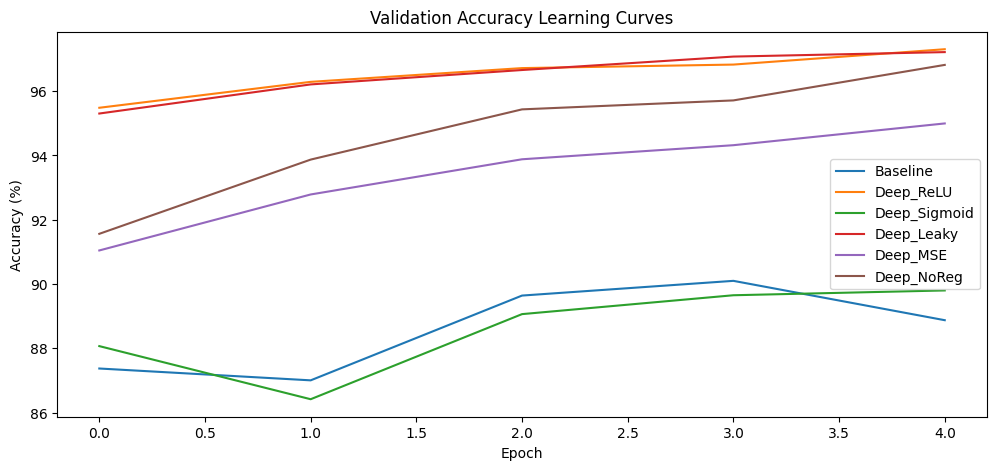

In [ ]:
plt.figure(figsize=(12, 5))

for name in histories:
    plt.plot(histories[name]['val_acc'], label=name)

plt.title("Validation Accuracy Learning Curves")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()

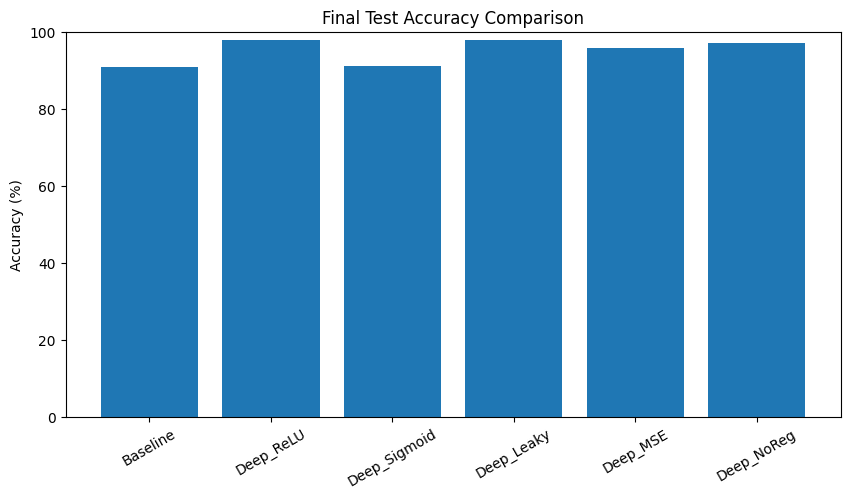

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(results.keys(), results.values())
plt.title("Final Test Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=30)
plt.ylim(0, 100)
plt.show()

In [ ]:
best_name = max(results, key=results.get)
best_model = models[best_name]

def run_fgsm_test(model, epsilon=0.1):
    model.eval()
    total_acc = 0
    n_batches = 0

    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        images.requires_grad = True

        outputs = model(images)
        loss = nn.CrossEntropyLoss()(outputs, labels)

        model.zero_grad()
        loss.backward()

        perturbed = images + epsilon * images.grad.sign()
        perturbed = torch.clamp(perturbed, -1, 1)

        with torch.no_grad():
            adv_outputs = model(perturbed)
            acc = accuracy_fn(adv_outputs, labels)

        total_acc += acc
        n_batches += 1

    return total_acc / n_batches

fgsm_acc = run_fgsm_test(best_model, epsilon=0.1)
print("Best model:", best_name)
print("FGSM Accuracy:", fgsm_acc)

Best model: Deep_ReLU
FGSM Accuracy: 86.44506369426752


In [ ]:
for name, acc in results.items():
    print(name, ":", round(acc, 2))

print("FGSM:", round(fgsm_acc, 2))

Baseline : 90.8
Deep_ReLU : 97.92
Deep_Sigmoid : 91.3
Deep_Leaky : 97.85
Deep_MSE : 95.9
Deep_NoReg : 97.19
FGSM: 86.45
